In [ ]:
# notebook for building CNN with cats & dogs dataset

In [2]:
!unzip /content/cats_dogs.zip -d /content/

Archive:  /content/cats_dogs.zip
   creating: /content/cats_dogs/
  inflating: /content/__MACOSX/._cats_dogs  
   creating: /content/cats_dogs/cats_set/
  inflating: /content/__MACOSX/cats_dogs/._cats_set  
  inflating: /content/cats_dogs/.DS_Store  
  inflating: /content/__MACOSX/cats_dogs/._.DS_Store  
   creating: /content/cats_dogs/dogs_set/
  inflating: /content/__MACOSX/cats_dogs/._dogs_set  
  inflating: /content/cats_dogs/cats_set/cat.4369.jpg  
  inflating: /content/__MACOSX/cats_dogs/cats_set/._cat.4369.jpg  
  inflating: /content/cats_dogs/cats_set/cat.4355.jpg  
  inflating: /content/__MACOSX/cats_dogs/cats_set/._cat.4355.jpg  
  inflating: /content/cats_dogs/cats_set/cat.4433.jpg  
  inflating: /content/__MACOSX/cats_dogs/cats_set/._cat.4433.jpg  
  inflating: /content/cats_dogs/cats_set/cat.4427.jpg  
  inflating: /content/__MACOSX/cats_dogs/cats_set/._cat.4427.jpg  
  inflating: /content/cats_dogs/cats_set/cat.4341.jpg  
  inflating: /content/__MACOSX/cats_dogs/cats_set/

In [3]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import random

In [ ]:
# Mount Google Drive in Colab

#from google.colab import drive
#drive.mount('/content/drive')



In [4]:
# Path to shared dataset folder in Google Drive

#data_dir = "/content/drive/MyDrive/Colab_Notebooks/CNN_Day2/cats_dogs"
data_dir = "/content/cats_dogs"

### Importing the raw cat and dog images

In [5]:
# importing the data (cat and dog images)


train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [6]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

GPU detected and available for TensorFlow.


In [7]:
# View labels from the first training batch

for images, labels in train_ds_raw.take(1):

    print(labels.numpy())
    print(train_ds_raw.class_names)

[0 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1]
['cats_set', 'dogs_set']


In [8]:
# class names
class_names = train_ds_raw.class_names
print(class_names)

['cats_set', 'dogs_set']


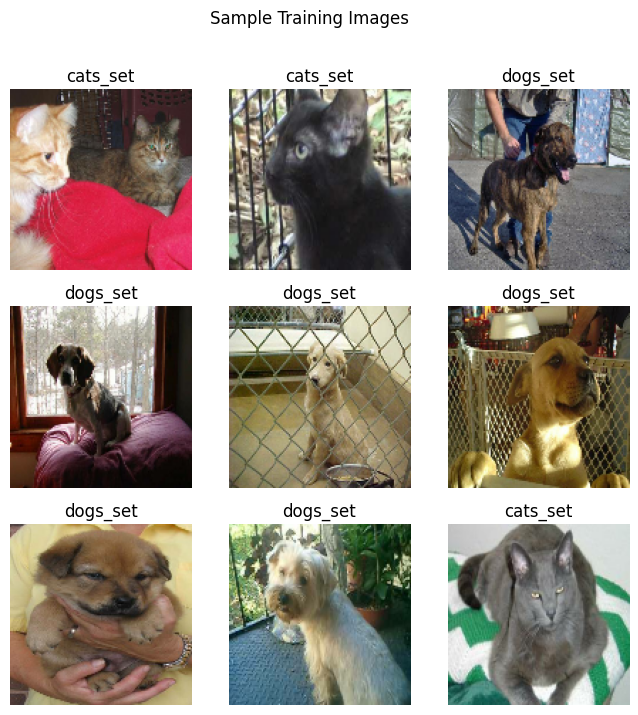

In [9]:
# View one batch of images
plt.figure(figsize=(8, 8))

for images, labels in train_ds_raw.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # display 0–255 RGB correctly
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()

### Importing padded cat and dog images

In [10]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


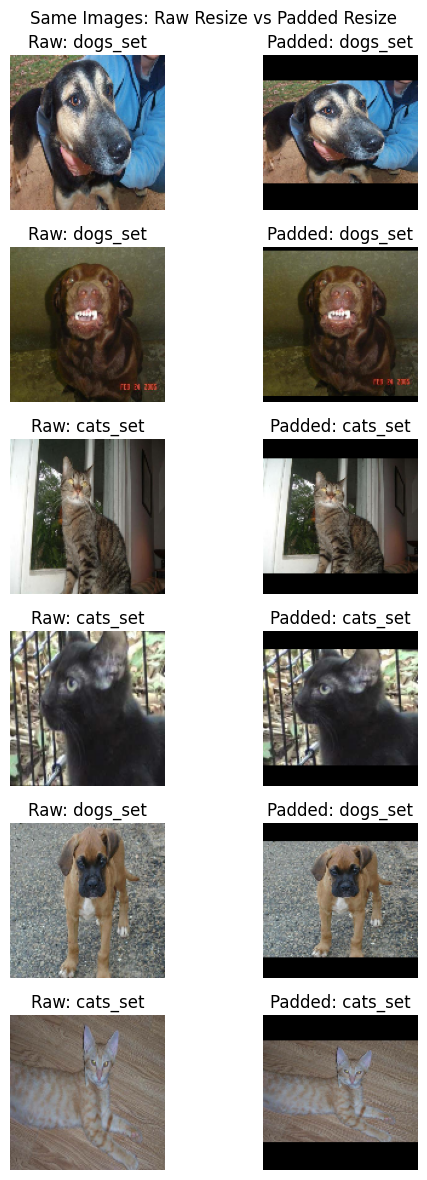

In [11]:
random.seed(42)

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    img = tf.io.read_file(str(path))
    img = tf.image.decode_jpeg(img, channels=3)

    raw_img = tf.image.resize(img, (128, 128))
    padded_img = tf.image.resize_with_pad(img, 128, 128)

    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img.numpy().astype("uint8"))
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()

### Normalize all data and shuffle train data

In [12]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

# Shuffle only the training data to improve learning
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

In [13]:
# check normalization worked correctly (should be 0–1 range)
for images, labels in train_ds_padded.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 1.0


### Building the MLP model

In [14]:
# set random seed for reproducibility
tf.random.set_seed(42)

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5138 - loss: 3.1094 - val_accuracy: 0.6154 - val_loss: 0.9323
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5713 - loss: 0.8776 - val_accuracy: 0.5288 - val_loss: 1.0047
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5962 - loss: 0.7246 - val_accuracy: 0.5288 - val_loss: 0.8751
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6062 - loss: 0.7937 - val_accuracy: 0.4712 - val_loss: 1.7772
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5838 - loss: 0.9267 - val_accuracy: 0.5096 - val_loss: 1.2314
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6675 - loss: 0.7302 - val_accuracy: 0.5288 - val_loss: 0.7663
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7525 - loss: 0.5154 - val_accuracy: 0.5577 - val_loss: 0.9903
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7250 - loss: 0.5370 - val_accuracy: 0.5288 - v

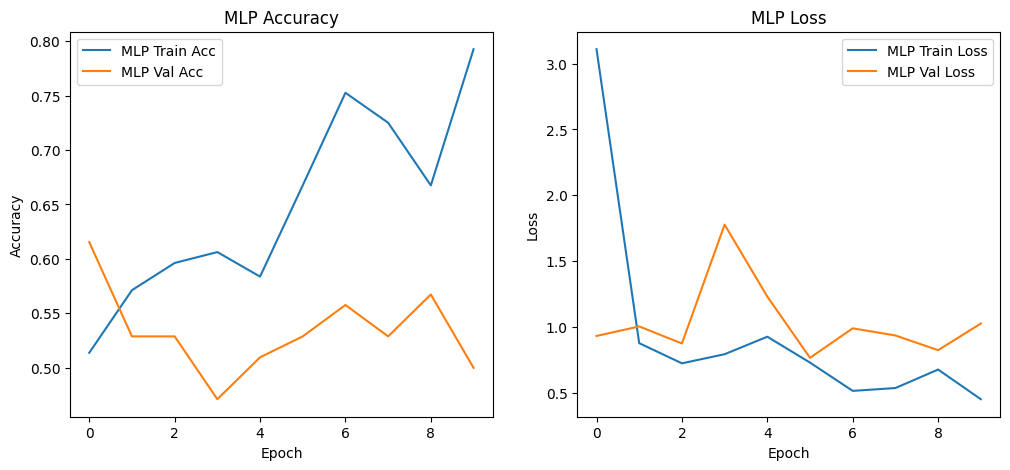

In [16]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [17]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20                                      # increase if needed
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.5575 - loss: 0.8529 - val_accuracy: 0.5385 - val_loss: 0.6996
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6375 - loss: 0.6373 - val_accuracy: 0.5096 - val_loss: 0.7258
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7350 - loss: 0.5441 - val_accuracy: 0.5481 - val_loss: 0.7781
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8000 - loss: 0.4380 - val_accuracy: 0.5769 - val_loss: 0.7302
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8550 - loss: 0.3374 - val_accuracy: 0.5769 - val_loss: 0.9128
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9100 - loss: 0.2484 - val_accuracy: 0.5865 - val_loss: 0.9360
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9450 - loss: 0.1468 - val_accuracy: 0.6154 - val_loss: 0.8744
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9887 - loss: 0.0769 - val_accuracy: 0.6154 - v

### Visualizing CNN performance

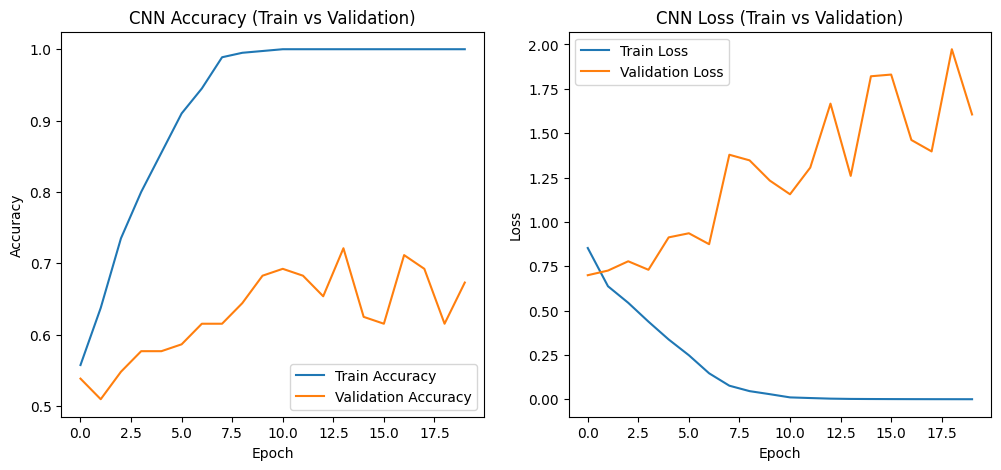

In [18]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [19]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping]                     # add early stopping callback
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5562 - loss: 0.8056 - val_accuracy: 0.5865 - val_loss: 0.6805
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6025 - loss: 0.6637 - val_accuracy: 0.4712 - val_loss: 0.7322
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6475 - loss: 0.6232 - val_accuracy: 0.6250 - val_loss: 0.6462
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6875 - loss: 0.5802 - val_accuracy: 0.5000 - val_loss: 0.7323
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7788 - loss: 0.4986 - val_accuracy: 0.6250 - val_loss: 0.6759
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8213 - loss: 0.3851 - val_accuracy: 0.5865 - val_loss: 0.7353
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9013 - loss: 0.2701 - val_accuracy: 0.5865 - val_loss: 0.7592
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9550 - loss: 0.1596 - val_accuracy: 0.6635 - v

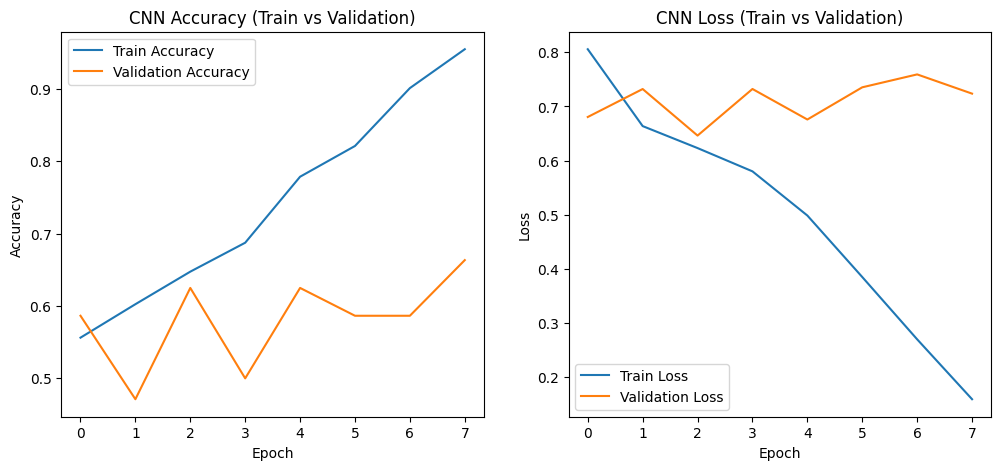

In [20]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [21]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5238 - loss: 1.0519 - val_accuracy: 0.5096 - val_loss: 0.6936
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5850 - loss: 0.6740 - val_accuracy: 0.5865 - val_loss: 0.6761
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6375 - loss: 0.6412 - val_accuracy: 0.4519 - val_loss: 0.8277
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6438 - loss: 0.6015 - val_accuracy: 0.5769 - val_loss: 0.7380
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7013 - loss: 0.5825 - val_accuracy: 0.5865 - val_loss: 0.6840
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6787 - loss: 0.5978 - val_accuracy: 0.5577 - val_loss: 0.6671
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7050 - loss: 0.5697 - val_accuracy: 0.5769 - val_loss: 0.7536
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7188 - loss: 0.5542 - val_accuracy: 0.6058 - v

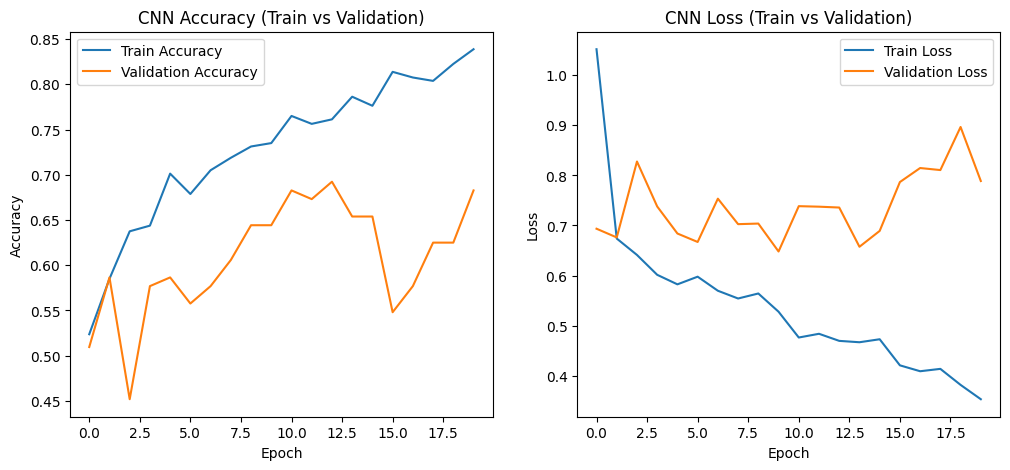

In [22]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [23]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5150 - loss: 0.7597 - val_accuracy: 0.5481 - val_loss: 0.6806
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5913 - loss: 0.6646 - val_accuracy: 0.5000 - val_loss: 0.7382
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6413 - loss: 0.6523 - val_accuracy: 0.5288 - val_loss: 0.7345
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6862 - loss: 0.6104 - val_accuracy: 0.5000 - val_loss: 0.7101
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6913 - loss: 0.5608 - val_accuracy: 0.5481 - val_loss: 0.7123
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7588 - loss: 0.4931 - val_accuracy: 0.6538 - val_loss: 0.6796
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8000 - loss: 0.4393 - val_accuracy: 0.6058 - val_loss: 0.7876
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8225 - loss: 0.3832 - val_accuracy: 0.6442 - v

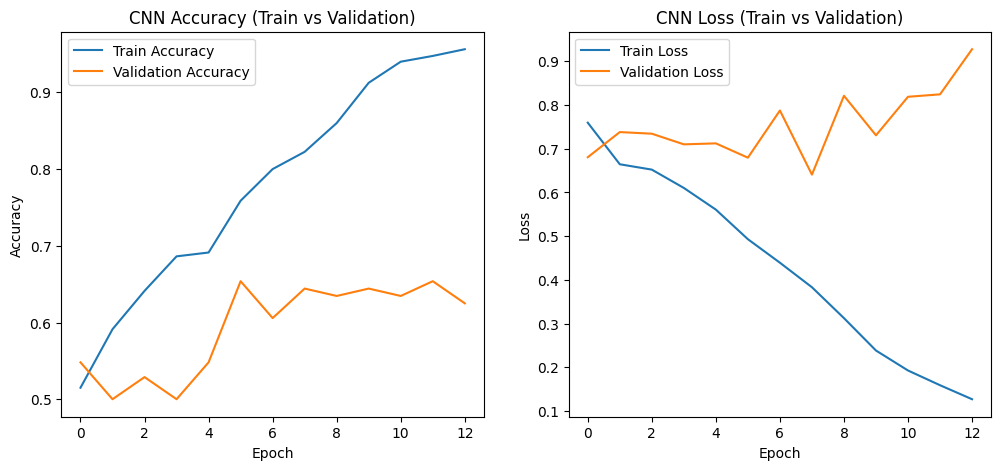

In [24]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

**Configuration 1**: Trying to have stronger augmentation

Uncommented:
- layers.RandomRotation(0.05)
- layers.RandomZoom(0.05)
- layers.RandomTranslation(0.05, 0.05)
- layers.RandomContrast(0.1)

In [25]:
# Your code here

# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.5350 - loss: 0.7795 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5625 - loss: 0.6848 - val_accuracy: 0.5385 - val_loss: 0.6839
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5938 - loss: 0.6699 - val_accuracy: 0.4423 - val_loss: 0.8093
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6200 - loss: 0.6526 - val_accuracy: 0.6154 - val_loss: 0.6616
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6400 - loss: 0.6289 - val_accuracy: 0.5865 - val_loss: 0.6845
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6463 - loss: 0.6168 - val_accuracy: 0.5000 - val_loss: 0.7715
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6500 - loss: 0.6249 - val_accuracy: 0.5385 - val_loss: 0.7386
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6750 - loss: 0.6074 - val_accuracy: 0.6250 - v

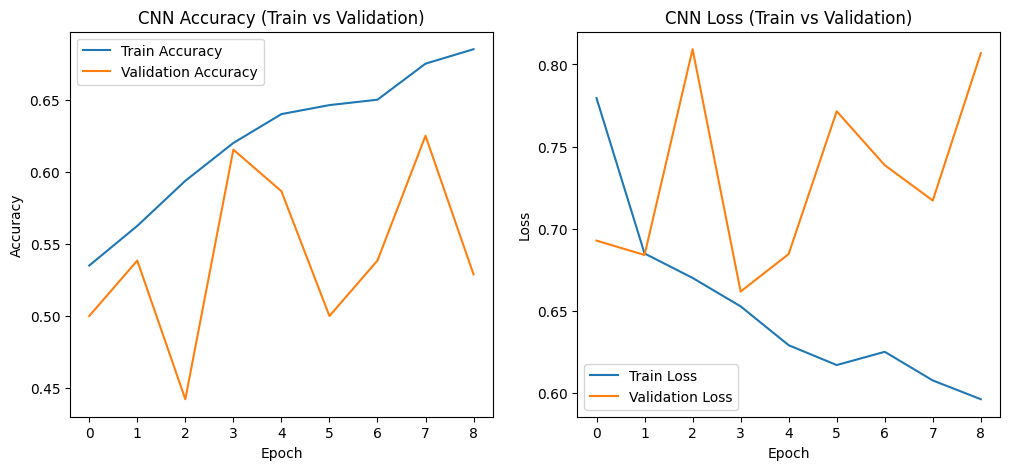

In [26]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

**Configuration 2**: Trying to reduce overfitting

Uncommented:
- kernel_regularizer=regularizers.l2(0.0005) (in both Conv2D & Dense layers)
- layers.Dropout(0.2),

In [27]:
# Your code here

# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.5075 - loss: 1.0963 - val_accuracy: 0.5769 - val_loss: 0.7683
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5788 - loss: 0.7536 - val_accuracy: 0.4712 - val_loss: 0.7718
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6112 - loss: 0.7258 - val_accuracy: 0.5962 - val_loss: 0.7530
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6350 - loss: 0.7046 - val_accuracy: 0.5096 - val_loss: 0.7598
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6637 - loss: 0.6746 - val_accuracy: 0.6346 - val_loss: 0.7084
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7038 - loss: 0.6566 - val_accuracy: 0.6346 - val_loss: 0.7161
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7088 - loss: 0.6205 - val_accuracy: 0.5962 - val_loss: 0.7329
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7525 - loss: 0.5908 - val_accuracy: 0.6635 - v

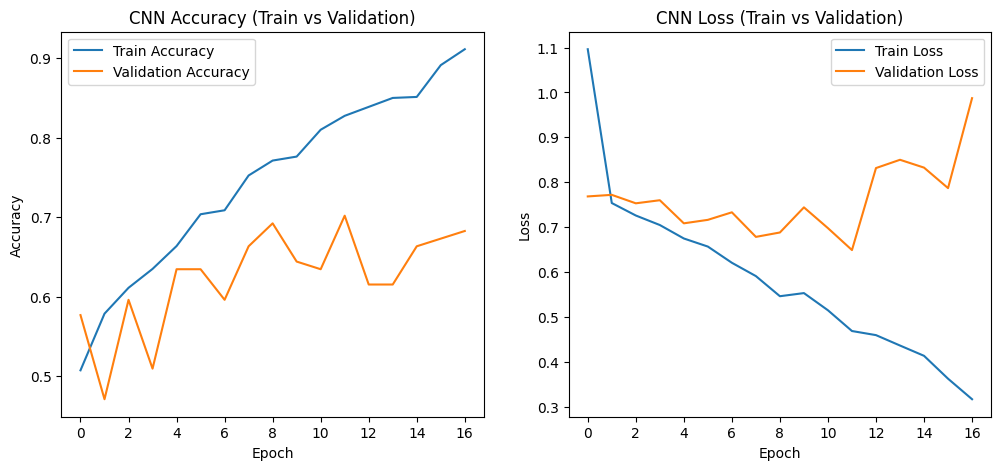

In [28]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

**Configuration 3**: Adding model capacity

Uncommented:
- the entire third convolution block
- layers.Dropout(0.2)

In [29]:
# your code here

# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    layers.Conv2D(
         128, (3, 3),
         padding="same",
         # kernel_regularizer=regularizers.l2(0.0005)
     ),
      layers.BatchNormalization(),
      layers.Activation("relu"),
      layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug]
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5500 - loss: 1.4966 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5838 - loss: 0.6747 - val_accuracy: 0.5385 - val_loss: 0.6933
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6037 - loss: 0.6671 - val_accuracy: 0.5192 - val_loss: 0.6930
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6087 - loss: 0.6696 - val_accuracy: 0.5577 - val_loss: 0.6915
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6062 - loss: 0.6551 - val_accuracy: 0.5192 - val_loss: 0.6918
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6400 - loss: 0.6305 - val_accuracy: 0.6154 - val_loss: 0.6894
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6413 - loss: 0.6166 - val_accuracy: 0.6250 - val_loss: 0.6846
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6162 - loss: 0.6357 - val_accuracy: 0.5673 - v

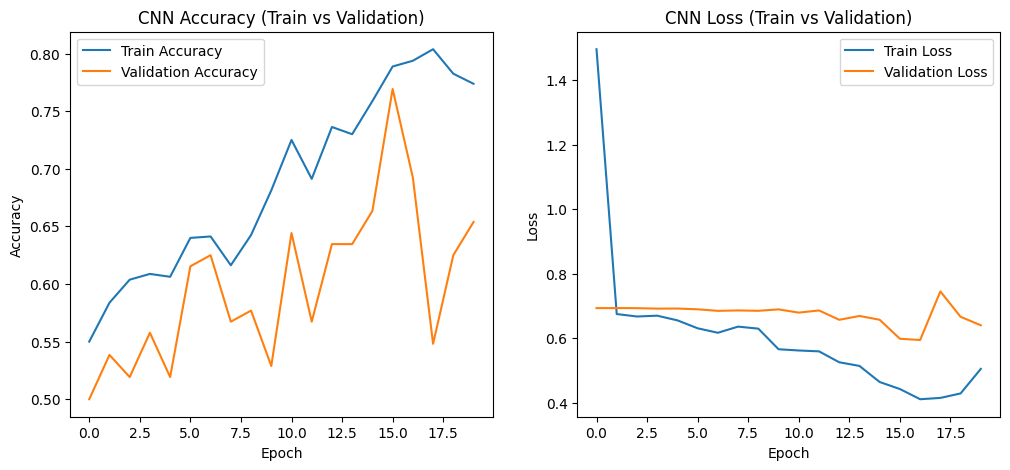

In [30]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### What seemed to help model performance most in your experiments?

- The model that performed best was **Configuration 3**, which added a third convolutional layer with 128 filters, Batch Normalization, and Dropout. This model reached the highest test accuracy of 0.7188.

- Configuration 1 used stronger data augmentation, including rotation, zoom, translation, and contrast. It achieved a test accuracy of 0.6146. This did not improve performance much, likely because the augmentation made the training images harder without adding enough model capacity.

- Configuration 2 used L2 regularization and Dropout to reduce overfitting. It improved test accuracy to 0.6667, which suggests that regularization helped the model generalize better than augmentation alone.

- **Configuration 3** performed the best because adding another convolutional layer gave the model more capacity to learn higher-level image features, while Batch Normalization and Dropout helped control overfitting. Overall, increasing model capacity carefully seemed to help the most.